In [1]:
# === ENVIRONMENT & FILEPATH SETUP ===
import os
import sys
import ctypes
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

try:
    ctypes.CDLL("/home/emmy/miniconda3/envs/mlbio_gpu/lib/python3.10/site-packages/nvidia/cu13/lib/libnvJitLink.so.13")
except Exception:
    pass

codebase_path = "../"
if codebase_path not in sys.path:
    sys.path.insert(0, codebase_path)

for key in list(sys.modules.keys()):
    if key.startswith("src"):
        del sys.modules[key]

# DATA_DIR = f"{codebase_path}/output/cache"
DATA_DIR = f"{codebase_path}/data"
ENV_PATH = f"{codebase_path}/artifacts/.env"
MODELS_DIR = f"{codebase_path}/output/models"
ARTIFACTS_DIR = f"{codebase_path}/artifacts"

print("💻 Local Lab Server Environment Loaded.")

💻 Local Lab Server Environment Loaded.


/tmp/ipykernel_802061/4219129448.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(labels), palette='viridis', ax=ax)


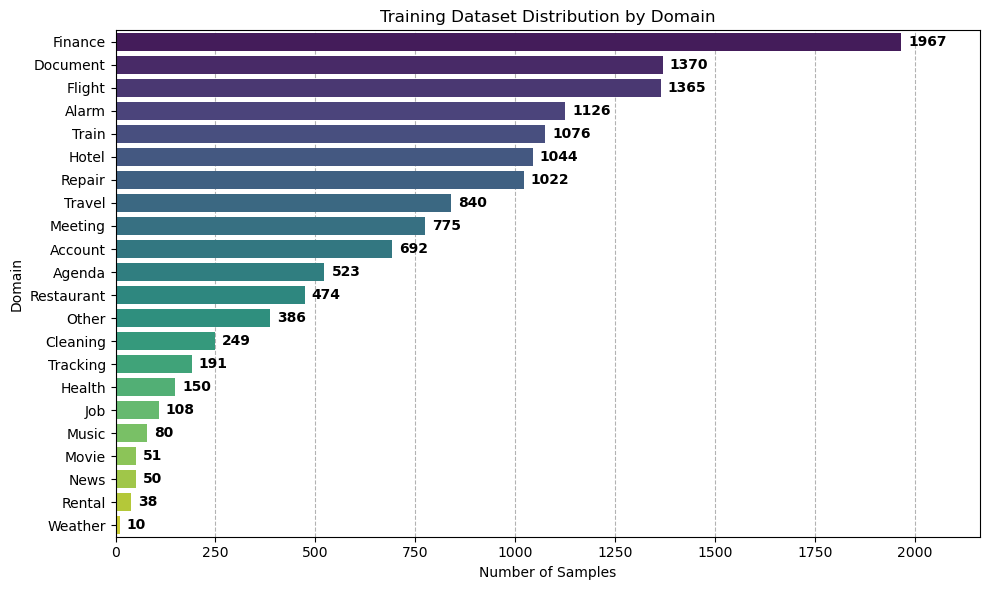

In [2]:
# == VISUALIZE TRAIN DATASET DISTRIBUTION ===
def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]
    
val_full = load_jsonl(f"{DATA_DIR}/train.jsonl")
dev_data = load_jsonl(f"{DATA_DIR}/addition.jsonl")

# Map tool names to domains based on addition.jsonl
tool_to_domain = {}

for item in dev_data:
    domain = item.get('domain', 'Unknown')
    for tool in item['tools']:
        tool_to_domain[tool['name']] = domain
        
def get_domain(row):
    correct_letter = row.get('answer')
    if correct_letter and 'options' in row and correct_letter in row['options']:
        correct_tool = row['options'][correct_letter]
        return tool_to_domain.get(correct_tool['name'], 'Unknown')
    return 'Unknown'

domains = [get_domain(item) for item in val_full]
domain_counts = Counter(domains)

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(10, 6))

# Sort domains by count for better visualization
sorted_domains = sorted(domain_counts.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_domains)

# Pass the ax object to Seaborn
sns.barplot(x=list(values), y=list(labels), palette='viridis', ax=ax)

# Add counts to the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, weight='bold')

# Adjust layout to prevent label clipping
plt.title('Training Dataset Distribution by Domain')
plt.xlabel('Number of Samples')
plt.ylabel('Domain')

# Give the right side extra padding so numbers do not get cut off
ax.set_xlim(0, max(values) * 1.1)

# Add vertical grid lines behind the bars
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)  # Sends grid lines to the back

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/dataset_domain_distribution.png", dpi=300)
plt.show()


## 1. Load Experiment Summary

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
plt.style.use('ggplot')

# Load data
csv_path = f"{ARTIFACTS_DIR}/experiment_summary.csv"
try:
    df_raw = pd.read_csv(csv_path)
    print(f"Loaded {len(df_raw)} raw experiment runs.")
    # Filter for the three main models to compare them together
    models_to_keep = [
        'ibm-granite/granite-3.1-2b-instruct',
        'mistralai/Mistral-Nemo-Instruct-2407',
        'Qwen/Qwen2.5-32B-Instruct'
    ]
    df = df_raw[df_raw['Model'].isin(models_to_keep)].copy()
    # Drop original Method column to avoid duplicates when renaming Training Strategy to Method
    if 'Method' in df.columns:
        df = df.drop(columns=['Method'])
    df = df.rename(columns={
        'Training Strategy': 'Method',
        'Prompt Format': 'Config',
        'Internal Validation Accuracy': 'Accuracy',
        'Semantic Confusion': 'SemanticConfusion',
        'Option Bias (A)': 'OptionBias_A',
        'Format Error Rate': 'FormatErrorRate'
    })
    # Clean values to match notebook expectations
    df['Config'] = df['Config'].replace({'StructOnly': 'StructuralOnly'})
    df['Method'] = df['Method'].replace({'Baseline': 'Prompt_ZeroShot', 'SFT - LoRA': 'SFT_LoRA', 'SFT - DoRA': 'SFT_DoRA'})
    # Create a short model name for plotting
    df['Model_Short'] = df['Model'].apply(lambda x: x.split('/')[-1])
    print(f"Filtered to {len(df)} runs for the three main models.")
    display(df)
except Exception as e:
    print(f"Could not load experiment summary. Error: {e}")
    # Create dummy data for layout testing
    df = pd.DataFrame([
        {'Method': 'Prompt_ZeroShot', 'Config': 'FullInfo', 'Accuracy': 0.65, 'FormatErrorRate': 0.12, 'SemanticConfusion': 0.85},
        {'Method': 'Prompt_ZeroShot', 'Config': 'StructuralOnly', 'Accuracy': 0.45, 'FormatErrorRate': 0.20, 'SemanticConfusion': 0.70},
        {'Method': 'SFT_LoRA', 'Config': 'FullInfo', 'Accuracy': 0.94, 'FormatErrorRate': 0.0, 'SemanticConfusion': 0.92},
        {'Method': 'SFT_LoRA', 'Config': 'StructuralOnly', 'Accuracy': 0.88, 'FormatErrorRate': 0.0, 'SemanticConfusion': 0.89}
    ])


Loaded 21 raw experiment runs.
Filtered to 13 runs for the three main models.


,Unnamed: 0,Method,Config,Model,Size (B),Accuracy,Kaggle Public Score,Epochs,LR,FormatErrorRate,SemanticConfusion,OptionBias_A,Latency Seconds,Worst-Performing Domain,Notes,Model_Short
6,NaN,Prompt_ZeroShot,FullInfo,ibm-granite/granite-3.1-2b-instruct,2.0,0.6704,-,-,-,0.3968,0.2309,0.4497,892.40,NaN,NaN,granite-3.1-2b-instruct
7,NaN,Prompt_ZeroShot,StructuralOnly,ibm-granite/granite-3.1-2b-instruct,2.0,0.5993,-,-,-,0.4826,0.2756,0.5125,795.60,NaN,NaN,granite-3.1-2b-instruct
8,NaN,SFT_LoRA,FullInfo,ibm-granite/granite-3.1-2b-instruct,2.0,0.9632,0.82485,1,2e-4,0.0015,0.6041,0.1408,367.27,NaN,NaN,granite-3.1-2b-instruct
9,NaN,SFT_LoRA,StructuralOnly,ibm-granite/granite-3.1-2b-instruct,2.0,0.9696,0.87570,1,2e-4,0.0010,0.5561,0.1383,276.08,NaN,NaN,granite-3.1-2b-instruct
10,NaN,SFT_DoRA,StructuralOnly,ibm-granite/granite-3.1-2b-instruct,2.0,0.9662,0.88418,1,2e-4,0.0010,0.5933,0.1403,1281.10,NaN,NaN,granite-3.1-2b-instruct
11,NaN,Prompt_ZeroShot,FullInfo,mistralai/Mistral-Nemo-Instruct-2407,12.0,0.8877,-,-,-,0.0020,0.5683,0.1354,1042.90,NaN,NaN,Mistral-Nemo-Instruct-2407
12,NaN,Prompt_ZeroShot,StructuralOnly,mistralai/Mistral-Nemo-Instruct-2407,12.0,0.9152,-,-,-,0.0010,0.5858,0.1216,705.18,NaN,NaN,Mistral-Nemo-Instruct-2407
13,NaN,SFT_LoRA,FullInfo,mistralai/Mistral-Nemo-Instruct-2407,12.0,0.9559,0.84180,1,2e-4,0.0010,0.5130,0.1496,1362.77,NaN,NaN,Mistral-Nemo-Instruct-2407
14,NaN,SFT_LoRA,StructuralOnly,mistralai/Mistral-Nemo-Instruct-2407,12.0,0.9701,0.89265,1,2e-4,0.0010,0.6458,0.1432,980.96,NaN,NaN,Mistral-Nemo-Instruct-2407
15,NaN,Prompt_ZeroShot,FullInfo,Qwen/Qwen2.5-32B-Instruct,32.0,0.9117,-,-,-,0.0019,0.5796,0.1387,2385.00,NaN,NaN,Qwen2.5-32B-Instruct


## 2. Q2 2x2 Comparison Table

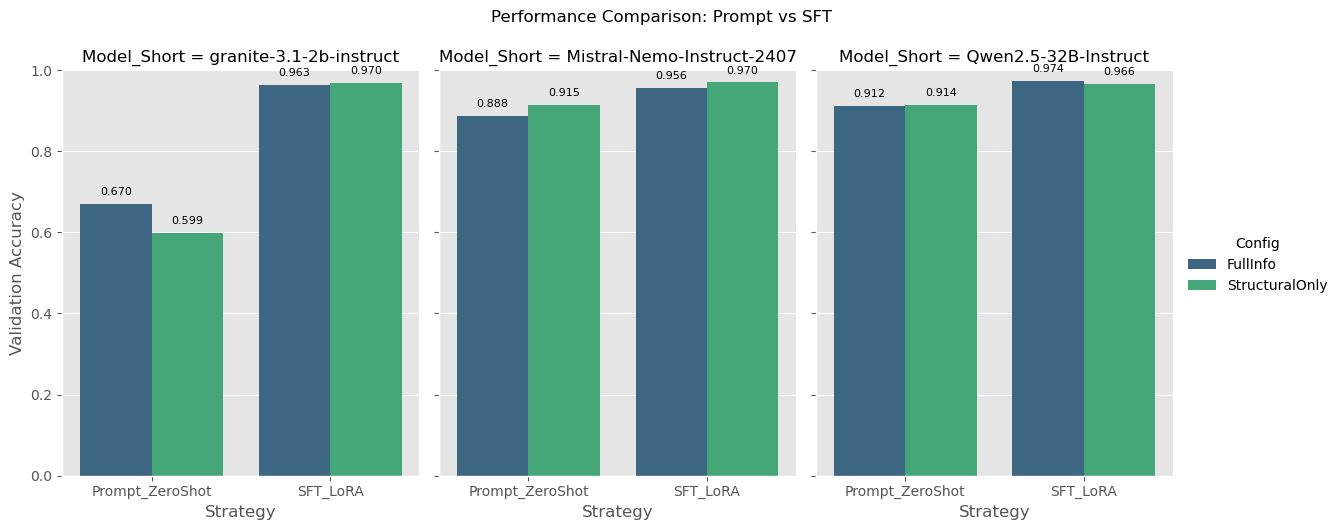

In [5]:
# Plot Accuracy Comparison across Models
if not df.empty:
    g = sns.catplot(
        data=df[df['Method'] != 'SFT_DoRA'], # Exclude DoRA for clean 2x2 comparison
        x='Method', 
        y='Accuracy', 
        hue='Config', 
        col='Model_Short', 
        kind='bar',
        palette='viridis',
        height=5,
        aspect=0.8
    )
    g.fig.suptitle("Performance Comparison: Prompt vs SFT", y=1.05)
    g.set_axis_labels("Strategy", "Validation Accuracy")
    g.set(ylim=(0, 1.0))
    
    # Add values on top of bars
    for ax in g.axes.flat:
        for p in ax.patches:
            if pd.notnull(p.get_height()) and p.get_height() > 0:
                ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=8)
    
    plt.savefig(f"{ARTIFACTS_DIR}/q2_comparison_chart.png", dpi=300, bbox_inches='tight')
    plt.show()


## 3. Q3 Tool Ambiguity (Semantic Confusion)

In [ ]:
if 'SemanticConfusion' in df.columns:
    g = sns.catplot(
        data=df[df['Method'] != 'SFT_DoRA'],
        x='Method', 
        y='SemanticConfusion', 
        hue='Config', 
        col='Model_Short', 
        kind='bar',
        palette='mako',
        height=5,
        aspect=0.8
    )
    g.fig.suptitle("Semantic Confusion of Incorrect Predictions", y=1.05)
    g.set_axis_labels("Strategy", "Average Cosine Similarity")
    g.set(ylim=(0, 1.0))
    plt.savefig(f"{ARTIFACTS_DIR}/q3_semantic_confusion.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Semantic Confusion Rate Context:")
    print("Higher semantic similarity on errors indicates the model is selecting semantically related tools (i.e., 'hard negatives') rather than making random errors.")


## 4. Q3 Option Bias Analysis

In [ ]:
if 'OptionBias_A' in df.columns:
    g = sns.catplot(
        data=df[df['Method'] != 'SFT_DoRA'],
        x='Method', 
        y='OptionBias_A', 
        hue='Config', 
        col='Model_Short', 
        kind='bar',
        palette='rocket',
        height=5,
        aspect=0.8
    )
    g.fig.suptitle("Bias Towards Option A (First Position Bias)", y=1.05)
    g.set_axis_labels("Strategy", "Frequency of Predicting 'A'")
    for ax in g.axes.flat:
        ax.axhline(y=0.125, color='red', linestyle='--', label='Expected (Random) = 12.5%')
    plt.savefig(f"{ARTIFACTS_DIR}/q3_option_bias.png", dpi=300, bbox_inches='tight')
    plt.show()


## 5. Training and Evaluation Metrics across SFT Models

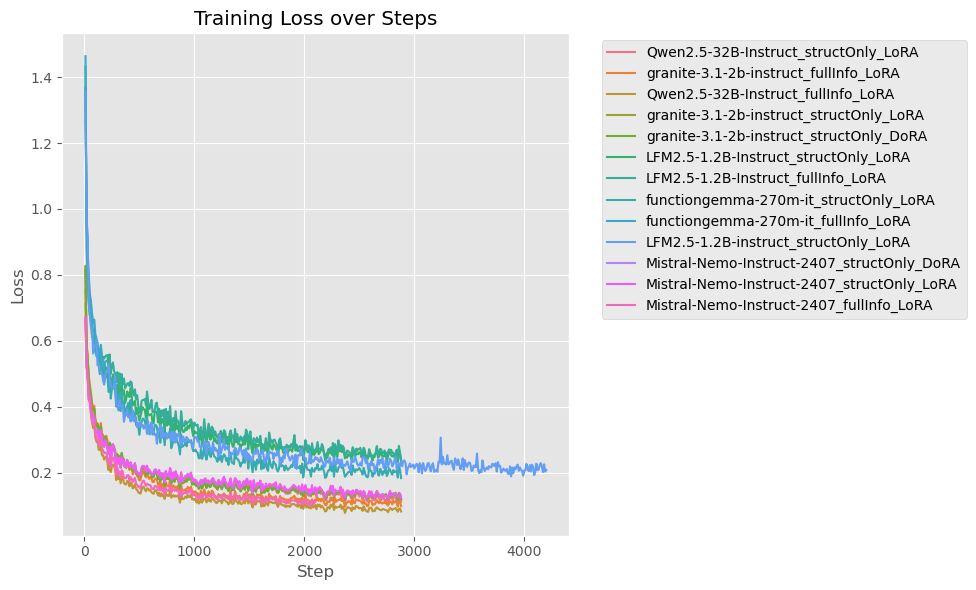

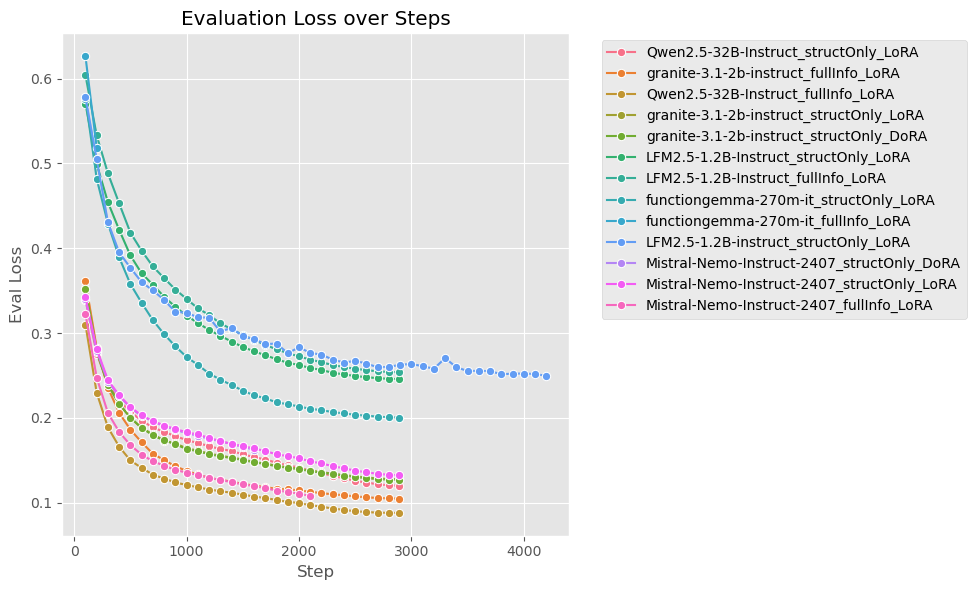

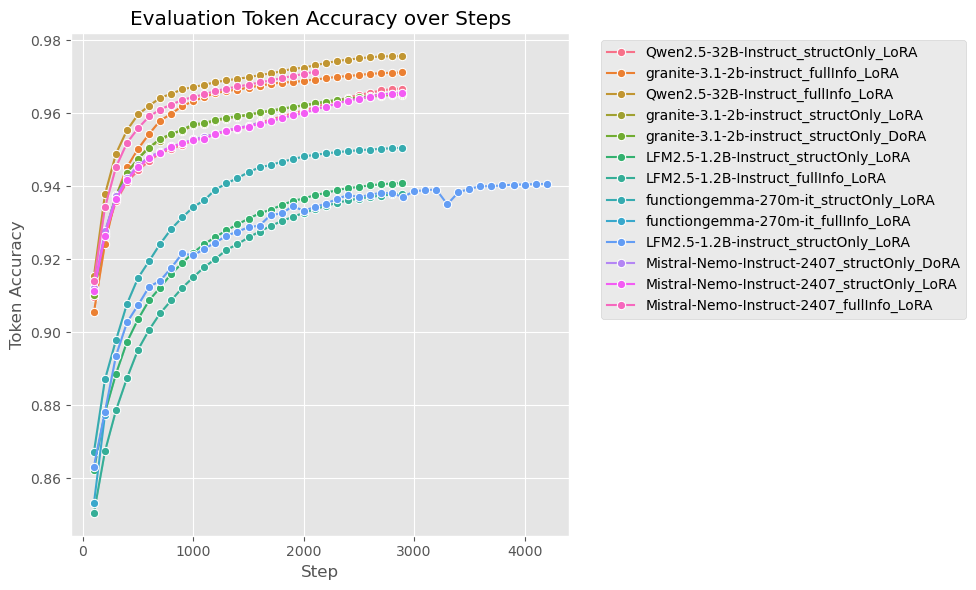

In [4]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load trainer_state.json files
files = glob.glob(f"{MODELS_DIR}/*/*/trainer_state.json")

train_data = []
eval_data = []

for f in files:
    model_name = f.split('/')[-3].replace('sft_', '')
    with open(f, 'r') as file:
        data = json.load(file)
        
    log_history = data.get('log_history', [])
    
    for log in log_history:
        if 'loss' in log and 'step' in log:
            train_data.append({
                'Model': model_name,
                'Step': log['step'],
                'Loss': log['loss'],
                'Entropy': log.get('entropy', None),
                'Token Accuracy': log.get('mean_token_accuracy', None)
            })
        if 'eval_loss' in log and 'step' in log:
            eval_data.append({
                'Model': model_name,
                'Step': log['step'],
                'Eval Loss': log['eval_loss'],
                'Eval Entropy': log.get('eval_entropy', None),
                'Eval Token Accuracy': log.get('eval_mean_token_accuracy', None)
            })

df_train = pd.DataFrame(train_data)
df_eval = pd.DataFrame(eval_data)

if not df_train.empty:
    # Plot Training Loss
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_train, x='Step', y='Loss', hue='Model')
    plt.title('Training Loss over Steps')
    plt.ylabel('Loss')
    plt.xlabel('Step')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # plt.savefig(f"{ARTIFACTS_DIR}/training_loss_plot.png", dpi=300)
    plt.show()

if not df_eval.empty:
    # Plot Eval Loss
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_eval, x='Step', y='Eval Loss', hue='Model', marker='o')
    plt.title('Evaluation Loss over Steps')
    plt.ylabel('Eval Loss')
    plt.xlabel('Step')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # plt.savefig(f"{ARTIFACTS_DIR}/eval_loss_plot.png", dpi=300)
    plt.show()

    # Plot Eval Token Accuracy
    if 'Eval Token Accuracy' in df_eval.columns:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df_eval, x='Step', y='Eval Token Accuracy', hue='Model', marker='o')
        plt.title('Evaluation Token Accuracy over Steps')
        plt.ylabel('Token Accuracy')
        plt.xlabel('Step')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        # plt.savefig(f"{ARTIFACTS_DIR}/eval_accuracy_plot.png", dpi=300)
        plt.show()
